In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import torchaudio
import torchaudio.transforms as T
import os
import glob
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"Torchaudio version: {torchaudio.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu126
Torchaudio version: 2.8.0+cu126
CUDA available: True
CUDA device: Tesla P100-PCIE-16GB


In [2]:

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(42)

INPUT_BASE = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
WORKING_BASE = '/kaggle/working'

STEMS_PATH = os.path.join(INPUT_BASE, 'genres_stems')
NOISE_PATH = os.path.join(INPUT_BASE, 'ESC-50-master/audio')
MASHUPS_PATH = os.path.join(INPUT_BASE, 'mashups')
TEST_CSV = os.path.join(INPUT_BASE, 'test.csv')

SYNTHETIC_OUTPUT_PATH = os.path.join(WORKING_BASE, 'synthetic_mashups/train')
FEATURES_OUTPUT_PATH = os.path.join(WORKING_BASE, 'features/train')

GENRES = ["blues", "classical", "country", "disco", "hiphop",
          "jazz", "metal", "pop", "reggae", "rock"]


In [3]:
def generate_synthetic_dataset(stems_dir, noise_dir, output_dir, samples_per_genre=50, target_sr=22050, duration=30):
    """Generates deterministic noisy mashups and saves them to /kaggle/working/."""
    
    genres = ["blues", "classical", "country", "disco", "hiphop",
              "jazz", "metal", "pop", "reggae", "rock"]
    target_length = target_sr * duration

    noise_files = glob.glob(os.path.join(noise_dir, '**', '*.wav'), recursive=True)
    print(f"Found {len(noise_files)} noise files")
    
    total_generated = 0
    
    for genre in genres:
        genre_out_dir = Path(output_dir) / genre
        genre_out_dir.mkdir(parents=True, exist_ok=True)
        
        song_folders = glob.glob(os.path.join(stems_dir, genre, '*'))
        if not song_folders:
            print(f"Warning: No songs found for genre {genre}")
            continue
        
        genre_count = 0
        for i in range(samples_per_genre):
            chosen_songs = random.sample(song_folders, 4)
            stems = []
            stem_types = ['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav']
            
            for song, stem_type in zip(chosen_songs, stem_types):
                stem_path = os.path.join(song, stem_type)
                if os.path.exists(stem_path):
                    waveform, sr = torchaudio.load(stem_path)

                    if sr != target_sr:
                        resampler = torchaudio.transforms.Resample(sr, target_sr)
                        waveform = resampler(waveform)

                    if waveform.shape[0] > 1:
                        waveform = torch.mean(waveform, dim=0, keepdim=True)

                    if waveform.shape[1] > target_length:
                        waveform = waveform[:, :target_length]
                    elif waveform.shape[1] < target_length:
                        waveform = torch.nn.functional.pad(waveform, (0, target_length - waveform.shape[1]))
                    
                    stems.append(waveform)
            
            if len(stems) == 4:
                
                mashup = torch.stack(stems).sum(dim=0)
                mashup = mashup / (torch.max(torch.abs(mashup)) + 1e-8)

                noise_file = random.choice(noise_files)
                noise, noise_sr = torchaudio.load(noise_file)

                if noise_sr != target_sr:
                    resampler = torchaudio.transforms.Resample(noise_sr, target_sr)
                    noise = resampler(noise)

                if noise.shape[0] > 1:
                    noise = torch.mean(noise, dim=0, keepdim=True)
                
                if noise.shape[1] > target_length:
                    noise = noise[:, :target_length]

                start_idx = random.randint(0, target_length - noise.shape[1])
                intensity = random.uniform(0.1, 0.4)
                
                mashup[:, start_idx:start_idx + noise.shape[1]] += (noise * intensity)
                mashup = mashup / (torch.max(torch.abs(mashup)) + 1e-8)

                out_path = genre_out_dir / f"mashup_{i:03d}.wav"
                torchaudio.save(str(out_path), mashup, target_sr)
                genre_count += 1
                total_generated += 1
        
        print(f"{genre}: {genre_count} mashups generated")
    
    print(f"\n Total mashups generated: {total_generated}")
    return total_generated

total_files = generate_synthetic_dataset(
    stems_dir=STEMS_PATH,
    noise_dir=NOISE_PATH,
    output_dir=SYNTHETIC_OUTPUT_PATH,
    samples_per_genre=50,
    target_sr=22050,
    duration=30
)

Found 2000 noise files
blues: 50 mashups generated
classical: 50 mashups generated
country: 50 mashups generated
disco: 50 mashups generated
hiphop: 50 mashups generated
jazz: 50 mashups generated
metal: 50 mashups generated
pop: 50 mashups generated
reggae: 50 mashups generated
rock: 50 mashups generated

 Total mashups generated: 500


In [4]:
def extract_and_save_features(input_dir, output_dir, target_sr=22050, n_fft=2048, hop_length=512, n_mels=128):
    """Converts audio to Mel-spectrograms in dB and saves as PyTorch tensors."""
    
    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=target_sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )
    amplitude_to_db = torchaudio.transforms.AmplitudeToDB()

    wav_files = glob.glob(os.path.join(input_dir, '**', '*.wav'), recursive=True)
    
    if not wav_files:
        print(f" Warning: No .wav files found in {input_dir}")
        return 0
    
    print(f"Found {len(wav_files)} .wav files to process")
    
    processed_count = 0
    for wav_path in wav_files:

        rel_path = os.path.relpath(wav_path, input_dir)
        out_path = Path(output_dir) / rel_path
        out_path = out_path.with_suffix('.pt')

        out_path.parent.mkdir(parents=True, exist_ok=True)

        waveform, sr = torchaudio.load(wav_path)
        mel_spec = mel_transform(waveform)
        mel_spec_db = amplitude_to_db(mel_spec)
        
        torch.save(mel_spec_db, out_path)
        processed_count += 1
    
    print(f"Successfully saved {processed_count} feature files to {output_dir}")
    return processed_count

features_count = extract_and_save_features(
    input_dir=SYNTHETIC_OUTPUT_PATH,
    output_dir=FEATURES_OUTPUT_PATH,
    target_sr=22050,
    n_fft=2048,
    hop_length=512,
    n_mels=128
)

Found 500 .wav files to process
Successfully saved 500 feature files to /kaggle/working/features/train


In [5]:
class PrecomputedFeatureDataset(Dataset):
    """Dataset class for loading pre-computed mel-spectrogram features."""
    
    def __init__(self, features_dir):
        self.files = glob.glob(os.path.join(features_dir, '**', '*.pt'), recursive=True)
        self.genres = sorted(['blues', 'classical', 'country', 'disco', 'hiphop', 
                              'jazz', 'metal', 'pop', 'reggae', 'rock'])
        self.genre_to_idx = {g: i for i, g in enumerate(self.genres)}
        self.idx_to_genre = {i: g for g, i in self.genre_to_idx.items()}
        
        print(f" Dataset loaded: {len(self.files)} samples")
        print(f"   Genres: {self.genres}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        genre = Path(file_path).parent.name
        label = self.genre_to_idx[genre]

        feature = torch.load(file_path)
        return feature, label

In [6]:
class CRNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.lstm = nn.LSTM(
            input_size=2048,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        
        self.fc = nn.Linear(64 * 2, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        b, c, f, t = x.shape 
        x = x.permute(0, 3, 1, 2)
        x = x.reshape(b, t, c * f) 
        lstm_out, _ = self.lstm(x)
        pooled, _ = torch.max(lstm_out, dim=1) 
        logits = self.fc(pooled) 
        
        return logits

In [7]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for features, labels in dataloader:
        features = features.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for features, labels in dataloader:
            features = features.to(device)
            labels = labels.to(device)
            
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return epoch_loss, epoch_acc, macro_f1, all_preds, all_labels

In [8]:
# --- PREPARE DATA ---
full_dataset = PrecomputedFeatureDataset(FEATURES_OUTPUT_PATH)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

 Dataset loaded: 500 samples
   Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Training samples: 400
Validation samples: 100
Total parameters: 1,102,666
Trainable parameters: 1,102,666


In [10]:
# --- TRAINING ---
num_epochs = 10
best_f1 = 0.0
best_model_state = None

metrics = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, all_preds, all_labels = validate(model, val_loader, criterion, device)

    metrics['train_loss'].append(train_loss)
    metrics['train_acc'].append(train_acc)
    metrics['val_loss'].append(val_loss)
    metrics['val_acc'].append(val_acc)
    metrics['val_f1'].append(val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_model_state = model.state_dict().copy()
    
    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

model.load_state_dict(best_model_state)
print(f"\n Training complete! Best Validation F1: {best_f1:.4f}")

model_path = '/kaggle/working/crnn_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_f1': best_f1,
    'metrics': metrics,
}, model_path)

print(f" Model saved to {model_path}")

Epoch  1/10 | Train Loss: 0.9854 | Train Acc: 0.8325 | Val Loss: 1.2836 | Val Acc: 0.6000 | Val F1: 0.5788
Epoch  2/10 | Train Loss: 0.9006 | Train Acc: 0.8425 | Val Loss: 1.2784 | Val Acc: 0.6400 | Val F1: 0.6001
Epoch  3/10 | Train Loss: 0.8110 | Train Acc: 0.8825 | Val Loss: 1.1822 | Val Acc: 0.6900 | Val F1: 0.6691
Epoch  4/10 | Train Loss: 0.7034 | Train Acc: 0.9250 | Val Loss: 1.1130 | Val Acc: 0.7000 | Val F1: 0.6898
Epoch  5/10 | Train Loss: 0.6634 | Train Acc: 0.9300 | Val Loss: 1.1751 | Val Acc: 0.6700 | Val F1: 0.6453
Epoch  6/10 | Train Loss: 0.6058 | Train Acc: 0.9300 | Val Loss: 1.0543 | Val Acc: 0.7000 | Val F1: 0.6984
Epoch  7/10 | Train Loss: 0.5273 | Train Acc: 0.9650 | Val Loss: 1.0537 | Val Acc: 0.6600 | Val F1: 0.6469
Epoch  8/10 | Train Loss: 0.4572 | Train Acc: 0.9825 | Val Loss: 0.9608 | Val Acc: 0.7200 | Val F1: 0.7063
Epoch  9/10 | Train Loss: 0.4198 | Train Acc: 0.9825 | Val Loss: 0.9840 | Val Acc: 0.7500 | Val F1: 0.7334
Epoch 10/10 | Train Loss: 0.3701 | Tr


----- CLASSIFICATION REPORT -----
              precision    recall  f1-score   support

       blues     0.6667    1.0000    0.8000         8
   classical     1.0000    0.9091    0.9524        11
     country     0.6250    0.8333    0.7143        12
       disco     0.5455    0.5455    0.5455        11
      hiphop     1.0000    0.9167    0.9565        12
        jazz     0.7273    0.7273    0.7273        11
       metal     0.9091    0.7692    0.8333        13
         pop     0.6667    0.8000    0.7273         5
      reggae     0.5000    0.6667    0.5714         3
        rock     0.5000    0.2857    0.3636        14

    accuracy                         0.7300       100
   macro avg     0.7140    0.7453    0.7192       100
weighted avg     0.7348    0.7300    0.7220       100



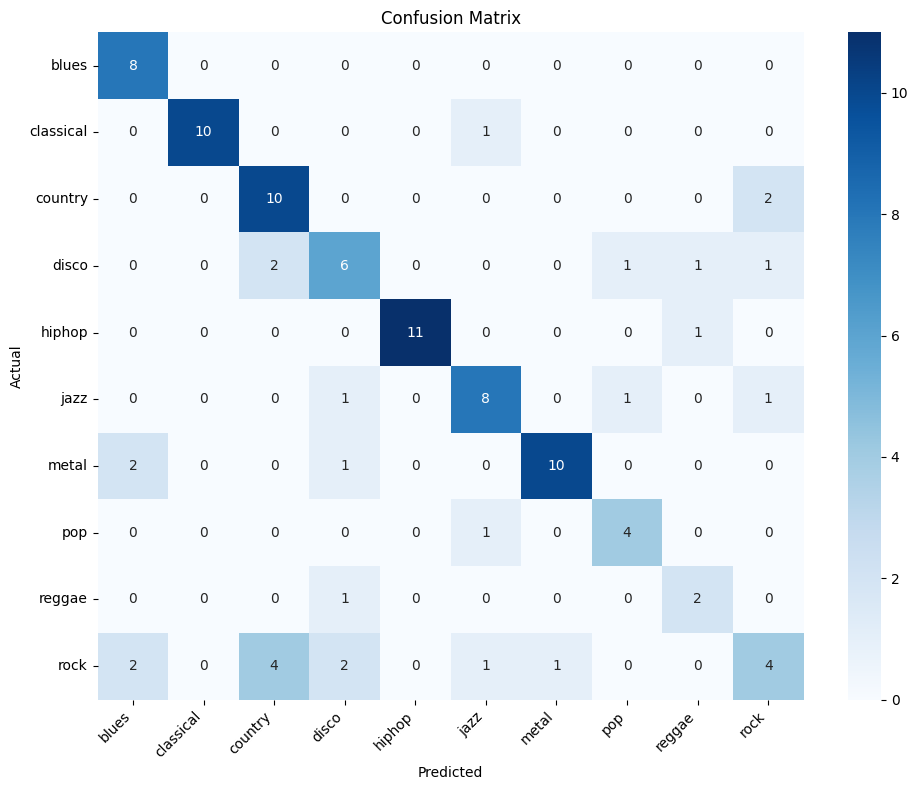

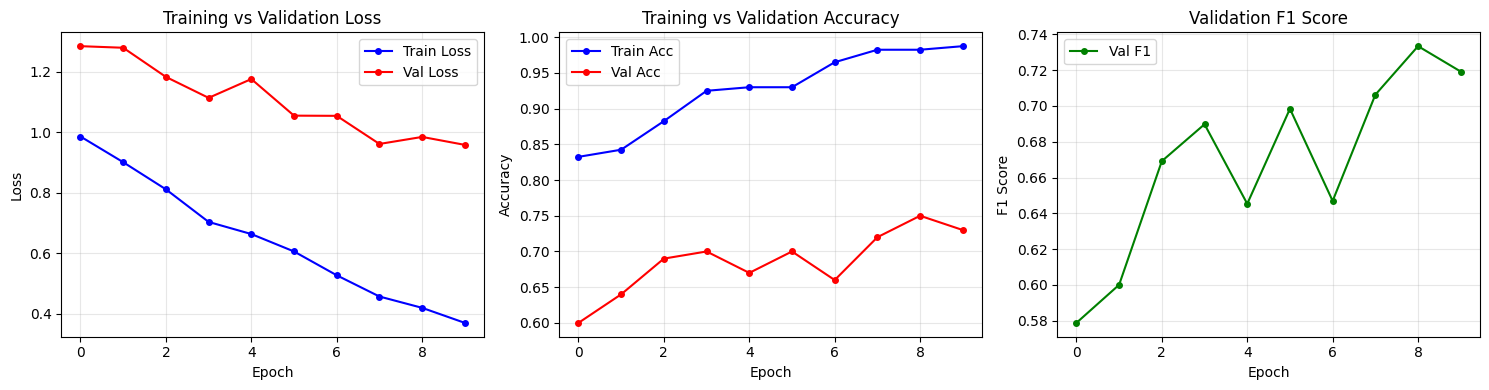

In [11]:
# --- VISUALIZATION ---
model.eval()
all_preds = []
all_labels_list = []

with torch.no_grad():
    for features, labels in val_loader:
        features = features.to(device)
        outputs = model(features)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels_list.extend(labels.numpy())

print("\n----- CLASSIFICATION REPORT -----")
print(classification_report(all_labels_list, all_preds, target_names=GENRES, digits=4))

# Confusion Matrix
cm = confusion_matrix(all_labels_list, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Training Curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss plot
axes[0].plot(metrics['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(metrics['val_loss'], 'r-o', label='Val Loss', markersize=4)
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(metrics['train_acc'], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(metrics['val_acc'], 'r-o', label='Val Acc', markersize=4)
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score plot
axes[2].plot(metrics['val_f1'], 'g-o', label='Val F1', markersize=4)
axes[2].set_title('Validation F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Q1) You ran the generate_synthetic_dataset script with samples_per_genre=50. If the script executed successfully across all 10 target genres, exactly how many .wav files should now exist in your /kaggle/working/synthetic_mashups/train/ directory tree?
#### Ans: `500`

#### Q2) Load any of your newly generated .wav files using torchaudio.load(). Given our configuration (target_sr=22050, duration=30), what is the exact tensor shape of the resulting waveform?
#### Ans: `(1, 661500)`

In [12]:
wav_path = glob.glob(os.path.join(SYNTHETIC_OUTPUT_PATH, '**', '*.wav'), recursive=True)[0]
waveform, sr = torchaudio.load(wav_path)

print(f"\nLoaded file: {wav_path}")
print(f"Sample rate: {sr} Hz")
print(f"Waveform shape: {tuple(waveform.shape)}")


Loaded file: /kaggle/working/synthetic_mashups/train/classical/mashup_010.wav
Sample rate: 22050 Hz
Waveform shape: (1, 661500)


#### Q3) Using the extract_and_save_features script with n_fft=2048, hop_length=512, and n_mels=128, you converted the waveforms into .pt files. 
#### If you load one of these pre-computed tensors using torch.load(), what is its exact dimension shape?
#### Ans: `(1, 128, 1292)`

In [13]:
feature_path = glob.glob(os.path.join(FEATURES_OUTPUT_PATH, '**', '*.pt'), recursive=True)[0]
feature = torch.load(feature_path)

print(f"\nLoaded file: {feature_path}")
print(f"Feature shape: {tuple(feature.shape)}")


Loaded file: /kaggle/working/features/train/classical/mashup_002.pt
Feature shape: (1, 128, 1292)


#### Q4) Inside the CRNN model's forward pass, the data moves from the CNN backbone to the LSTM. If your input batch has a size of 32, what is the exact shape of the tensor immediately after the second MaxPool2d(2) layer, right before the .permute() operation?
#### Ans: `(32, 64, 32, 323)`

In [14]:
test_model = CRNN(num_classes=10)
dummy_input = torch.randn(32, 1, 128, 1293)

cnn_output = test_model.cnn(dummy_input)
print(f"Output shape: {tuple(cnn_output.shape)}")

Output shape: (32, 64, 32, 323)


#### Q5) Your model uses a Bidirectional LSTM with input_size=2048 and hidden_size=64. Write a small snippet using sum(p.numel() for p in model.lstm.parameters() if p.requires_grad) to calculate the exact number of trainable parameters in the LSTM layer alone. What is that integer value?
#### Ans: `1082368`

In [15]:
lstm_params = sum(p.numel() for p in test_model.lstm.parameters() if p.requires_grad)
print(lstm_params)

1082368


#### Q6) When applying a 2D CNN to a Mel-spectrogram, translation invariance along the X-axis (Time) is highly beneficial, as a guitar solo at 0:15 is the same as a guitar solo at 0:25. However, why is translation invariance along the Y-axis (Mel-Frequency Bins) conceptually problematic for music?
#### Ans: `Moving a pattern up the Y-axis fundamentally changes its pitch and instrument identity.`